<a href="https://colab.research.google.com/github/khalilullahalfaath/kkpm_multi-task-learning/blob/main/mtl_seg_dep_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Cloud: Multi-task Semantic Segmentation and Depth Estimation
=====================

Overview
----------------
1. Memahami struktur dataset cityscapes (https://www.cityscapes-dataset.com/)
2. Mendesain arsitektur sebuah MTL model CNN encoder-decoder sederhana
3. Membuat beberapa fungsi pendukung (dataloader, train-val-test, dll)
4. Train-val-test model



In [1]:
#https://colab.research.google.com/github/oskarnatan/mtl-bisaai/blob/main/mtl_seg_dep_colab.ipynb
#https://colab.research.google.com/drive/1TxwaD-j6CTteFRLXfUnSNazqrY2g2qhT?authuser=2
# mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


INSPEKSI DATA
=====================


In [2]:
#Download data dari: https://www.cityscapes-dataset.com/downloads/

rootdir = "/content/drive/MyDrive/Kuliah/S-2 Universitas Gadjah Mada/Semester 2/KKPM/seg_dep/"
dir_rgb = rootdir+"cityscapes/leftImg8bit_trainvaltest/leftImg8bit/"
dir_seg = rootdir+"cityscapes/gtFine_trainvaltest/gtFine/"
dir_dep = rootdir+"cityscapes/disparity_trainvaltest/disparity/"


print(dir_rgb)
print(dir_seg)
print(dir_dep)

/content/drive/MyDrive/Kuliah/S-2 Universitas Gadjah Mada/Semester 2/KKPM/seg_dep/cityscapes/leftImg8bit_trainvaltest/leftImg8bit/
/content/drive/MyDrive/Kuliah/S-2 Universitas Gadjah Mada/Semester 2/KKPM/seg_dep/cityscapes/gtFine_trainvaltest/gtFine/
/content/drive/MyDrive/Kuliah/S-2 Universitas Gadjah Mada/Semester 2/KKPM/seg_dep/cityscapes/disparity_trainvaltest/disparity/


Part 1: visualisasi gambar dan inspeksi dimensi
----------------

(1024, 2048, 3)


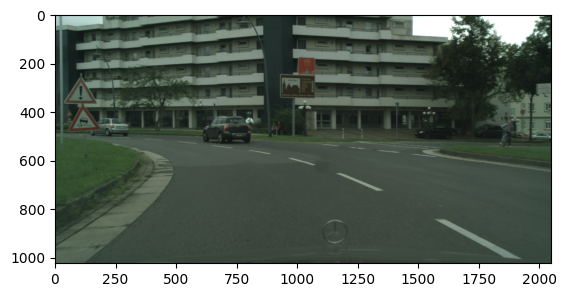

In [3]:
#import library yang diperlukan
%matplotlib inline
from matplotlib import pyplot as plt
import cv2
import os

part = 'train/' #train val test
town = 'aachen/' #pilih salah satu kota
idx = 0


#list semua file yang ada pada salah satu town di direktori RGB
list_file = os.listdir(dir_rgb+part+town)
list_file.sort() #urutkan
filename = list_file[idx] #ambil salah satu file

#tampilkan
image = cv2.imread(dir_rgb+part+town+filename)
image = image[:, :, [2, 1, 0]]
print(image.shape)
plt.imshow(image)
plt.show()

Part 2: load GT segmentation dan depth
----------------

(1024, 2048, 3)


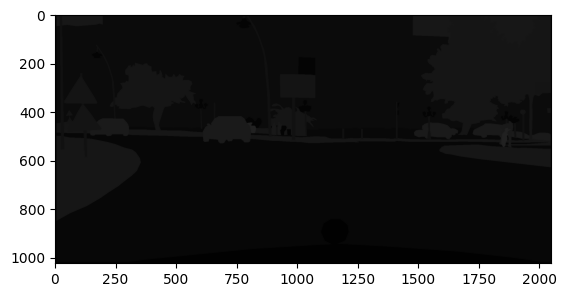

(1024, 2048)


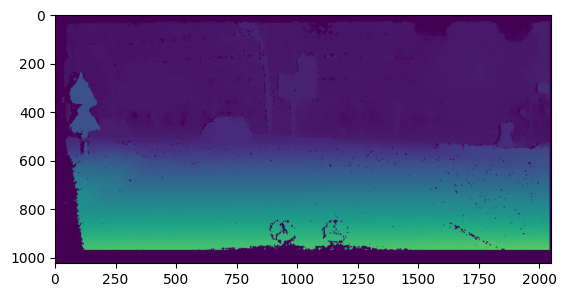

In [4]:
import numpy as np

#list semua file yang ada pada salah satu town di direktori SEG
list_file = os.listdir(dir_seg+part+town)
list_file.sort() #urutkan
filename = list_file[5*idx + 2] #ambil salah satu file

#tampilkan
seg_gt = cv2.imread(dir_seg+part+town+filename)
print(seg_gt.shape)
plt.imshow(seg_gt)
plt.show()

#list semua file yang ada pada salah satu town di direktori DEP
list_file = os.listdir(dir_dep+part+town)
list_file.sort() #urutkan
filename = list_file[idx] #ambil salah satu file

#lakukan hal yang sama untuk depth
dep_gt = cv2.imread(dir_dep+part+town+filename, cv2.IMREAD_UNCHANGED).astype(np.float32)
print(dep_gt.shape)
plt.imshow(dep_gt)
plt.show()

Part 3: visualisasi GT segmentation dan depth
----------------

In [5]:
#Define colormap dan konversi label dari 35 class ke 20 class
#BACA https://github.com/mcordts/cityscapesScripts/blob/master/cityscapesscripts/helpers/labels.py
SEG_MAP = {
    'colors'        :[[0, 0, 0], [128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156],
                    [190, 153, 153], [153, 153, 153], [250, 170, 30], [220, 220, 0],
                    [107, 142, 35], [152, 251, 152], [70, 130, 180], [220, 20, 60],
                    [255, 0, 0], [0, 0, 142], [0, 0, 70], [0, 60, 100],
                    [0, 80, 100], [0, 0, 230], [119, 11, 32]],
    'classes'       : ['None', 'road', 'sidewalk', 'building', 'wall',
                        'fence', 'pole', 'traffic light', 'traffic sign',
                        'vegetation', 'terrain', 'sky', 'person',
                        'rider', 'car', 'truck', 'bus',
                        'train', 'motorcycle', 'bicycle'],
}

mapping_20 = {
        0: 0,
        1: 0,
        2: 0,
        3: 0,
        4: 0,
        5: 0,
        6: 0,
        7: 1,
        8: 2,
        9: 0,
        10: 0,
        11: 3,
        12: 4,
        13: 5,
        14: 0,
        15: 0,
        16: 0,
        17: 6,
        18: 0,
        19: 7,
        20: 8,
        21: 9,
        22: 10,
        23: 11,
        24: 12,
        25: 13,
        26: 14,
        27: 15,
        28: 16,
        29: 0,
        30: 0,
        31: 17,
        32: 18,
        33: 19,
        -1: 0
    }


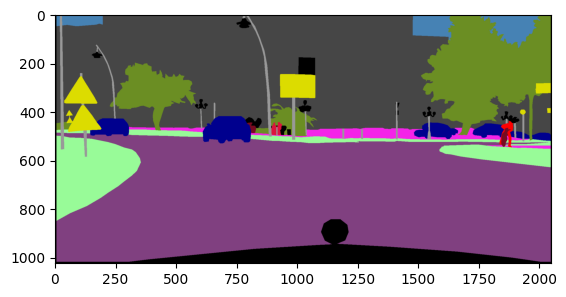

/tmp/ipykernel_12975/568987933.py:35: RuntimeWarning: divide by zero encountered in divide
  depth = (0.209313 * 2262.52) / img_d


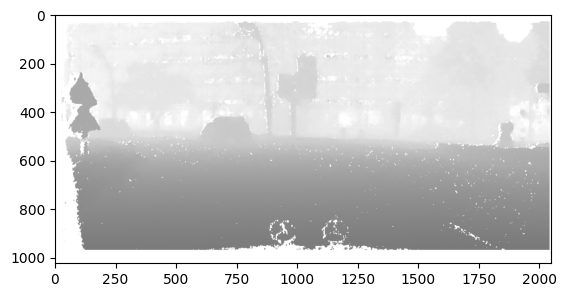

In [6]:
#visualisasi segmentation
def vis_seg(seg, SEG_CMAP):
    #buat array kosong untuk menyimpan output gambar
    imgx = np.zeros((seg.shape[0], seg.shape[1], 3))
    #warnai setiap label
    for cmap in SEG_CMAP['colors']:
        cmap_id = SEG_CMAP['colors'].index(cmap)
        imgx[np.where(seg == cmap_id)] = cmap
#         imgx = imgx[:, :, [2, 1, 0]]
    return imgx

#konversi dari 35 class ke 20 class
def encode_labels(mask, mapping_label):
    #inputnya adalah HWC hasil baca opencv
    mask = mask[:,:,0:1].reshape(mask.shape[0], mask.shape[1])  #ambil 1 channel dan reshape dari 3D ke 2D
    label_mask = np.zeros_like(mask)
    for k in mapping_label:
        label_mask[mask == k] = mapping_label[k]
    return label_mask


#untuk visualisasi logarithmic depth
def logdepth(normalized_depth):
    logdepth = np.ones(normalized_depth.shape) + (np.log(normalized_depth) / 5.70378)
    logdepth = np.clip(logdepth, 0.0, 1.0) * 255 #normalisasi ke 0 - 255
    logdepth = np.repeat(logdepth[:, :, np.newaxis], 3, axis=2)
    return logdepth

#konversi disparity ke depth
#baca https://github.com/mcordts/cityscapesScripts/blob/master/README.md#dataset-structure
def disp2dep(img_d, dep_max):
    #d = ( float(p) - 1. ) / 256
    img_d[img_d > 0] = (img_d[img_d > 0] - 1) / 256
    #depth = baseline * focal length / disparity
    depth = (0.209313 * 2262.52) / img_d
    #clip depth maximum ke 100 meter, karena langit nilai depthnya terlalu tinggi
    depth = np.minimum(depth, dep_max)
    return depth


#visualisasi GT segmentasi
seg_gtx = encode_labels(seg_gt, mapping_20)
seg_color = vis_seg(seg_gtx, SEG_MAP)
plt.imshow(seg_color.astype(np.uint8))
plt.show()


#visualisasi GT logarithmic depth
dep_gtx = disp2dep(dep_gt, 100)/100  #dinormalisasi ke 0 - 1
dep_log = logdepth(dep_gtx)
plt.imshow(dep_log.astype(np.uint8))
plt.show()




Part 4: Inspeksi setiap class channel pada GT segmentation
----------------

shape GT segmentation yang telah dikonversi dari 35c ke 20c:  (1024, 2048)
shape GT segmentation one hot encoded:  (1024, 2048, 20)
idx class:  0
nama class:  None


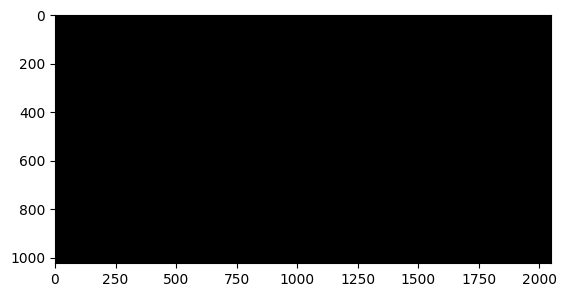

idx class:  1
nama class:  road


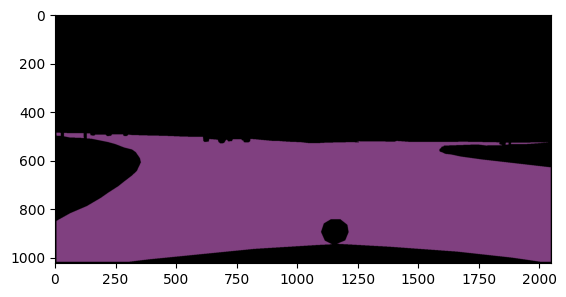

idx class:  2
nama class:  sidewalk


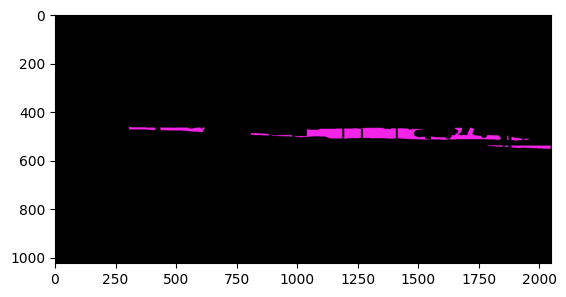

idx class:  3
nama class:  building


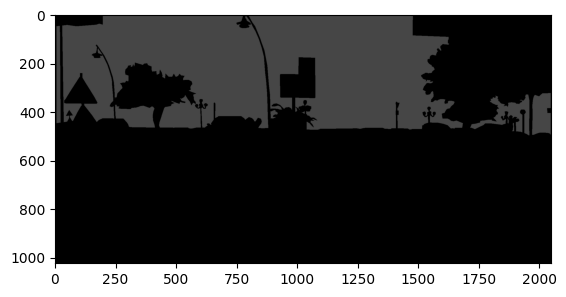

idx class:  4
nama class:  wall


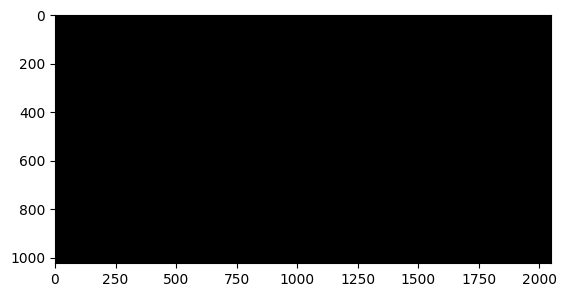

idx class:  5
nama class:  fence


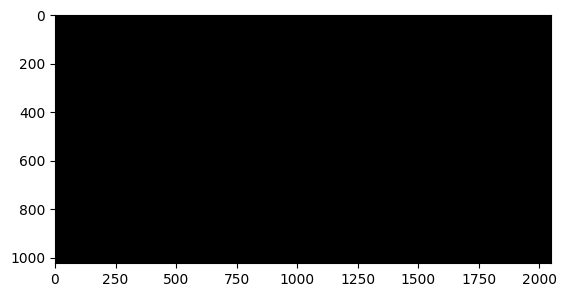

idx class:  6
nama class:  pole


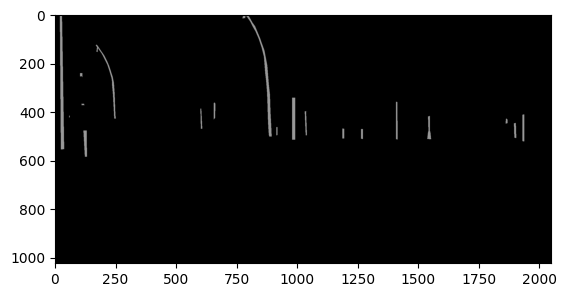

idx class:  7
nama class:  traffic light


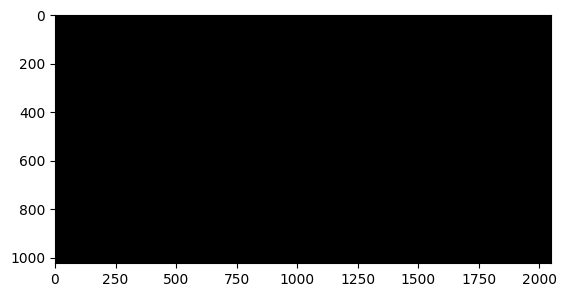

idx class:  8
nama class:  traffic sign


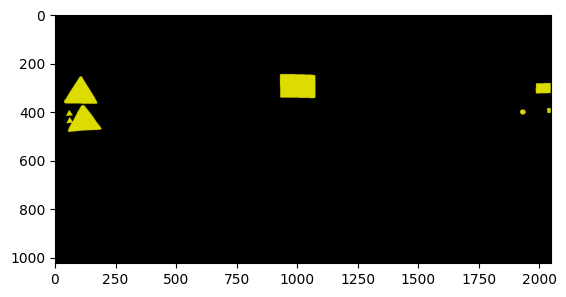

idx class:  9
nama class:  vegetation


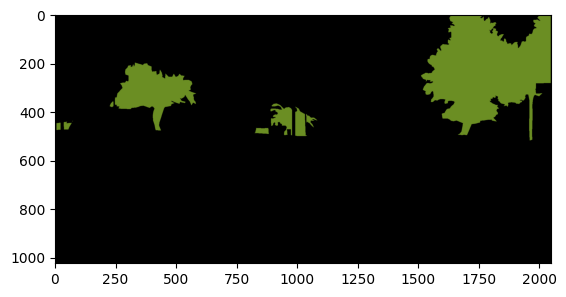

idx class:  10
nama class:  terrain


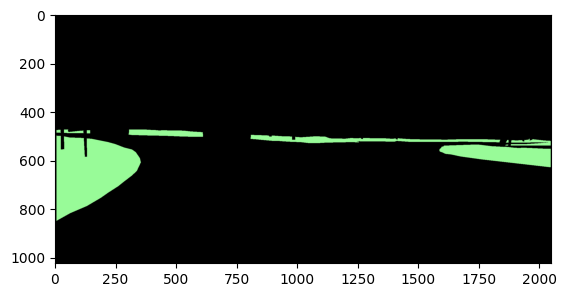

idx class:  11
nama class:  sky


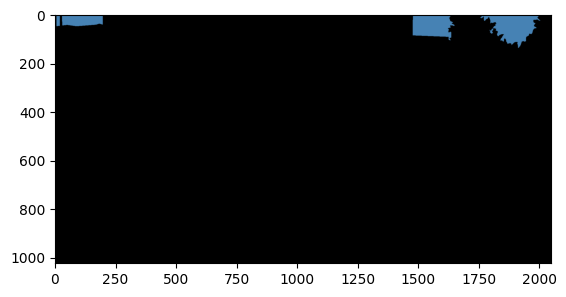

idx class:  12
nama class:  person


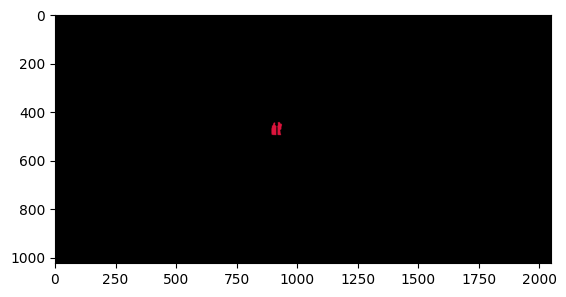

idx class:  13
nama class:  rider


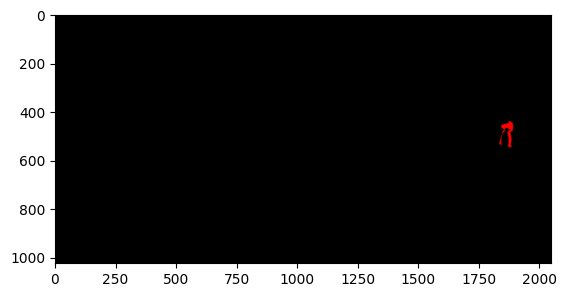

idx class:  14
nama class:  car


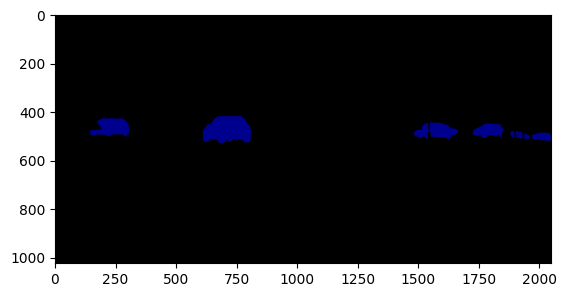

idx class:  15
nama class:  truck


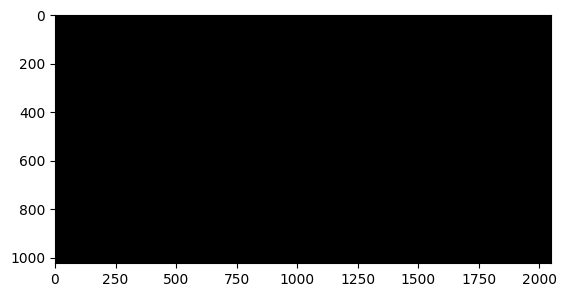

idx class:  16
nama class:  bus


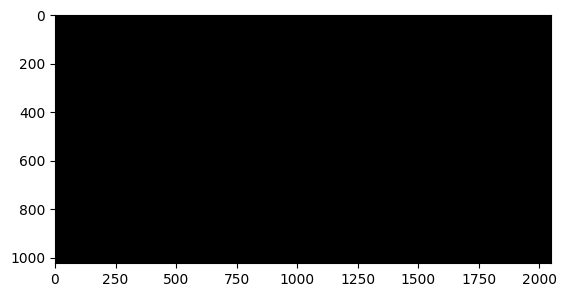

idx class:  17
nama class:  train


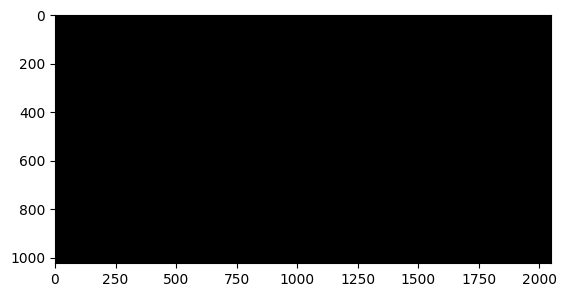

idx class:  18
nama class:  motorcycle


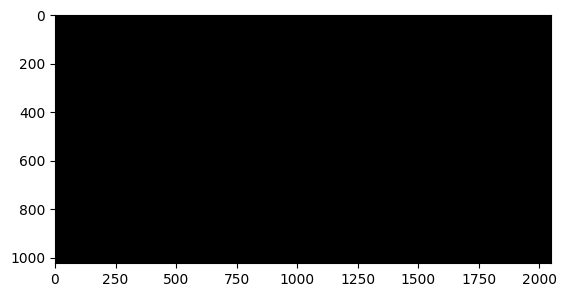

idx class:  19
nama class:  bicycle


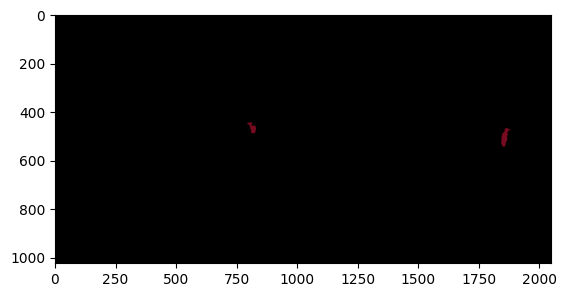

In [7]:
#konversi dari class id ke representasi one-hot encoding
def cls2one_hot(ss_gt20, n_class):
    one_hot = (np.arange(n_class) == ss_gt20[...,None]).astype(int)
    return one_hot

print("shape GT segmentation yang telah dikonversi dari 35c ke 20c: ",seg_gtx.shape)
seg_one_hot = cls2one_hot(seg_gtx, n_class=len(SEG_MAP['classes']))
print("shape GT segmentation one hot encoded: ",seg_one_hot.shape)

for i in range(seg_one_hot.shape[2]):
    print('idx class: ',i)
    print('nama class: ',SEG_MAP['classes'][i])
    img_class_r = seg_one_hot[:, :, i:i+1] * SEG_MAP['colors'][i][0]
    img_class_g = seg_one_hot[:, :, i:i+1] * SEG_MAP['colors'][i][1]
    img_class_b = seg_one_hot[:, :, i:i+1] * SEG_MAP['colors'][i][2]
    img_class_rgb = np.concatenate([img_class_r, img_class_g, img_class_b], axis=2)
    plt.imshow(img_class_rgb.astype(np.uint8))
    plt.show()




MENDESAIN ARSITEKTUR MTL UNET
=====================


In [8]:
import torch.nn as nn
import torch.nn.functional as F
from torch import cat
from torchvision import models
import torchvision.transforms as transforms


class ConvBNRelu(nn.Module):
    def __init__(self, channelx, stridex=1, kernelx=3, paddingx=1):
        super(ConvBNRelu, self).__init__()
        self.conv = nn.Conv2d(channelx[0], channelx[1], kernel_size=kernelx, stride=stridex, padding=paddingx, padding_mode='zeros')
        self.bn = nn.BatchNorm2d(channelx[1])
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        y = self.relu(x)
        return y

class ConvBlock(nn.Module):
    def __init__(self, channel, final=False):
        super(ConvBlock, self).__init__()
        #conv block
        if final:
            self.conv_block0 = ConvBNRelu(channelx=[channel[0], channel[0]], stridex=1)
            self.conv_block1 = nn.Sequential(
            nn.Conv2d(channel[0], channel[1], kernel_size=1)
            )
        else:
            self.conv_block0 = ConvBNRelu(channelx=[channel[0], channel[1]], stridex=1)
            self.conv_block1 = ConvBNRelu(channelx=[channel[1], channel[1]], stridex=1)


    def forward(self, x):
        #convolutional block
        y = self.conv_block0(x)
        y = self.conv_block1(y)
        return y


class resunet_mtl(nn.Module): #
    def __init__(self):
        super().__init__()
        n_fmap = [64, 64, 128, 256, 512]

        #RGB
        self.rgb_normalizer = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        self.RGB_encoder = models.resnet34(pretrained=True) #resnet18
        self.RGB_encoder.fc = nn.Sequential() #cara paling gampang untuk menghilangkan fc layer yang tidak diperlukan
        self.RGB_encoder.avgpool = nn.Sequential()

        #SEG
        self.conv3_ss_f = ConvBlock(channel=[n_fmap[4]+n_fmap[3], n_fmap[3]])
        self.conv2_ss_f = ConvBlock(channel=[n_fmap[3]+n_fmap[2], n_fmap[2]])
        self.conv1_ss_f = ConvBlock(channel=[n_fmap[2]+n_fmap[1], n_fmap[1]])
        self.conv0_ss_f = ConvBlock(channel=[n_fmap[1]+n_fmap[0], n_fmap[0]])
        self.final_ss_f = ConvBlock(channel=[n_fmap[0], 20], final=True)

        #DEPTH
        self.conv3_dep_f = ConvBlock(channel=[n_fmap[4]+n_fmap[3], n_fmap[3]])
        self.conv2_dep_f = ConvBlock(channel=[n_fmap[3]+n_fmap[2], n_fmap[2]])
        self.conv1_dep_f = ConvBlock(channel=[n_fmap[2]+n_fmap[1], n_fmap[1]])
        self.conv0_dep_f = ConvBlock(channel=[n_fmap[1]+n_fmap[0], n_fmap[0]])
        self.final_dep_f = ConvBlock(channel=[n_fmap[0], 1], final=True)

        #aktivasi final
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, rgb):
        #bagian downsampling
        in_rgb = self.rgb_normalizer(rgb)
        x_RGB = self.RGB_encoder.conv1(in_rgb)
        x_RGB = self.RGB_encoder.bn1(x_RGB)
        RGB_features0 = self.RGB_encoder.relu(x_RGB)
        RGB_features1 = self.RGB_encoder.layer1(self.RGB_encoder.maxpool(RGB_features0))
        RGB_features2 = self.RGB_encoder.layer2(RGB_features1)
        RGB_features3 = self.RGB_encoder.layer3(RGB_features2)
        RGB_features4 = self.RGB_encoder.layer4(RGB_features3)
        up_RGB_features4 = F.interpolate(RGB_features4, size=RGB_features3.size()[-2:], mode='bilinear', align_corners=True)

        #bagian segmentation
        ss_f_3 = self.conv3_ss_f(cat([up_RGB_features4, RGB_features3], dim=1))
        up_ss_f_3 = F.interpolate(ss_f_3, size=RGB_features2.size()[-2:], mode='bilinear', align_corners=True)
        ss_f_2 = self.conv2_ss_f(cat([up_ss_f_3, RGB_features2], dim=1))
        up_ss_f_2 = F.interpolate(ss_f_2, size=RGB_features1.size()[-2:], mode='bilinear', align_corners=True)
        ss_f_1 = self.conv1_ss_f(cat([up_ss_f_2, RGB_features1], dim=1))
        up_ss_f_1 = F.interpolate(ss_f_1, size=RGB_features0.size()[-2:], mode='bilinear', align_corners=True)
        ss_f_0 = self.conv0_ss_f(cat([up_ss_f_1, RGB_features0], dim=1))
        up_ss_f_0 = F.interpolate(ss_f_0, size=in_rgb.size()[-2:], mode='bilinear', align_corners=True)
        ss_f = self.sigmoid(self.final_ss_f(up_ss_f_0))

        #bagian depth estimation
        dep_f_3 = self.conv3_dep_f(cat([up_RGB_features4, RGB_features3], dim=1))
        up_dep_f_3 = F.interpolate(dep_f_3, size=RGB_features2.size()[-2:], mode='bilinear', align_corners=True)
        dep_f_2 = self.conv2_dep_f(cat([up_dep_f_3, RGB_features2], dim=1))
        up_dep_f_2 = F.interpolate(dep_f_2, size=RGB_features1.size()[-2:], mode='bilinear', align_corners=True)
        dep_f_1 = self.conv1_dep_f(cat([up_dep_f_2, RGB_features1], dim=1))
        up_dep_f_1 = F.interpolate(dep_f_1, size=RGB_features0.size()[-2:], mode='bilinear', align_corners=True)
        dep_f_0 = self.conv0_dep_f(cat([up_dep_f_1, RGB_features0], dim=1))
        up_dep_f_0 = F.interpolate(dep_f_0, size=in_rgb.size()[-2:], mode='bilinear', align_corners=True)
        dep_f = self.relu(self.final_dep_f(up_dep_f_0))

        return ss_f, dep_f


print(resunet_mtl())

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


resunet_mtl(
  (rgb_normalizer): Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  (RGB_encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

MEMBUAT FUNGSI-FUNGSI PENDUKUNG
=====================


A. DATALOADER DAN FUNGSI PENDUKUNGNYA
----------------


In [9]:
from torch.utils.data import Dataset

#Define colormap dan konversi label dari 35 class ke 20 class
#BACA https://github.com/mcordts/cityscapesScripts/blob/master/cityscapesscripts/helpers/labels.py
SEG_MAP = {
    'colors'        :[[0, 0, 0], [128, 64, 128], [244, 35, 232], [70, 70, 70], [102, 102, 156],
                    [190, 153, 153], [153, 153, 153], [250, 170, 30], [220, 220, 0],
                    [107, 142, 35], [152, 251, 152], [70, 130, 180], [220, 20, 60],
                    [255, 0, 0], [0, 0, 142], [0, 0, 70], [0, 60, 100],
                    [0, 80, 100], [0, 0, 230], [119, 11, 32]],
    'classes'       : ['None', 'road', 'sidewalk', 'building', 'wall',
                        'fence', 'pole', 'traffic light', 'traffic sign',
                        'vegetation', 'terrain', 'sky', 'person',
                        'rider', 'car', 'truck', 'bus',
                        'train', 'motorcycle', 'bicycle'],
}

mapping_20 = {
        0: 0,
        1: 0,
        2: 0,
        3: 0,
        4: 0,
        5: 0,
        6: 0,
        7: 1,
        8: 2,
        9: 0,
        10: 0,
        11: 3,
        12: 4,
        13: 5,
        14: 0,
        15: 0,
        16: 0,
        17: 6,
        18: 0,
        19: 7,
        20: 8,
        21: 9,
        22: 10,
        23: 11,
        24: 12,
        25: 13,
        26: 14,
        27: 15,
        28: 16,
        29: 0,
        30: 0,
        31: 17,
        32: 18,
        33: 19,
        -1: 0
    }


#konversi dari 35 class ke 20 class
def encode_labels(mask, mapping_label):
    #inputnya adalah HWC hasil baca opencv
    mask = mask[:,:,0:1].reshape(mask.shape[0], mask.shape[1])  #ambil 1 channel dan reshape dari 3D ke 2D
    label_mask = np.zeros_like(mask)
    for k in mapping_label:
        label_mask[mask == k] = mapping_label[k]
    return label_mask

#konversi dari class id ke representasi one-hot encoding
def cls2one_hot(ss_gt20, n_class):
    one_hot = (np.arange(n_class) == ss_gt20[...,None]).astype(int)
    return one_hot

#konversi disparity ke depth
#baca https://github.com/mcordts/cityscapesScripts/blob/master/README.md#dataset-structure
def disp2dep(img_d_raw, dep_max):
    # Initialize depth array with dep_max for invalid (0) disparity pixels
    depth = np.full_like(img_d_raw, fill_value=dep_max, dtype=np.float32)

    # Create a mask for valid disparity values (pixel_value > 0)
    valid_mask = img_d_raw > 0

    # Calculate metric disparity for valid pixels: disparity = pixel_value / 256.0
    metric_disparity = img_d_raw[valid_mask].astype(np.float32) / 256.0

    # Calculate depth for valid pixels: depth = baseline * focal_length / metric_disparity
    # Add a small epsilon to metric_disparity to prevent division by zero,
    # although for valid (pixel_value > 0) inputs, metric_disparity should also be > 0.
    # Using a mask for this operation to only modify valid depth values
    valid_depth_calculation_mask = (metric_disparity + 1e-7) > 0 # Ensure denominator is strictly positive
    depth[valid_mask][valid_depth_calculation_mask] = (0.209313 * 2262.52) / (metric_disparity[valid_depth_calculation_mask] + 1e-7)

    # Clip depth values to dep_max
    depth = np.minimum(depth, dep_max)
    return depth

#untuk mereduksi dimensi spasial supaya komputasi tidak terlalu berat
def resize_matrix(image, resize):
    #inputnya HWC
    WH_resized = (int(image.shape[1]/resize), int(image.shape[0]/resize))
    resized_image = cv2.resize(image, WH_resized, interpolation=cv2.INTER_NEAREST)

    return resized_image


#buat class dataset
class myData(Dataset):
    def __init__(self, root_dir, part):
        #buat list kosong dulu
        self.rgb = []
        self.seg = []
        self.dep = []

        #define folder masing2 untuk rgb seg dep
        rgb_folder = os.path.join(os.path.join(os.path.join(root_dir, 'leftImg8bit_trainvaltest'), 'leftImg8bit'), part)
        seg_folder = os.path.join(os.path.join(os.path.join(root_dir, 'gtFine_trainvaltest'), 'gtFine'), part)
        dep_folder = os.path.join(os.path.join(os.path.join(root_dir, 'disparity_trainvaltest'), 'disparity'), part)

        # list semua kota yang ada di RGB leftimg8bit
        town_list = os.listdir(rgb_folder)
        town_list.sort()
        for town in town_list:
            rgb_dir = os.path.join(rgb_folder, town)
            seg_dir = os.path.join(seg_folder, town)
            dep_dir = os.path.join(dep_folder, town)

            #list semua file
            file_list = os.listdir(rgb_dir)
            file_list.sort()
            for filename in file_list:
                #append ke list kosong tadi
                self.rgb.append(os.path.join(rgb_dir, filename))
                self.seg.append(os.path.join(seg_dir, filename[:-15]+'gtFine_labelIds.png'))
                self.dep.append(os.path.join(dep_dir, filename[:-15]+'disparity.png'))

    def __len__(self):
        return len(self.rgb)

    def __getitem__(self, index):
        data = dict()
        data['rgb'] = np.transpose(np.array(resize_matrix(
            cv2.imread(self.rgb[index]),
            resize=4)), (2, 0, 1)) # (H, W, C) --> (C, H, W)
        data['seg'] = np.transpose(np.array(resize_matrix(cls2one_hot(encode_labels(
            cv2.imread(self.seg[index]),
            mapping_label=mapping_20), n_class=len(SEG_MAP['classes'])), resize=4)), (2, 0, 1)) # (H, W, C) --> (C, H, W)
        data['dep'] = np.expand_dims(np.array(resize_matrix(disp2dep(
            cv2.imread(self.dep[index], cv2.IMREAD_UNCHANGED).astype(np.float32),
            dep_max=100), resize=4)), axis=0) / 100 #range dinormalisasi ke 0 - 1

        return data

B. TRAINING-VALIDATION
----------------


In [10]:
#!pip install --upgrade ipywidgets
from tqdm.notebook import tqdm

#Class untuk penyimpanan dan perhitungan update loss
class AverageMeter(object):
    def __init__(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0
    #update kalkulasi
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


#FUNGSI TRAINING
def train(data_loader, model, writer, cur_epoch, device, optimizer):
    #buat variabel untuk menyimpan kalkulasi loss
    loss_total = AverageMeter()
    loss_seg = AverageMeter()
    loss_dep = AverageMeter()

    #masuk ke mode training, pytorch
    model.train()

    #visualisasi progress training dengan tqdm
    prog_bar = tqdm()
    prog_bar.reset(total=len(data_loader))

    #training....
    total_batch = len(data_loader)
    batch_ke = 0
    for data in data_loader:
        cur_step = cur_epoch*total_batch + batch_ke

        dep_gt = data['dep'].to(device, dtype=torch.float)
        seg_gt = data['seg'].to(device, dtype=torch.float)
        image = data['rgb'].to(device, dtype=torch.float)

        #forward pass
        pred_seg, pred_dep = model(image)

        #kalkulasi loss
        bce_loss = F.binary_cross_entropy(pred_seg, seg_gt)
        mae_loss = F.l1_loss(pred_dep, dep_gt)
        total_loss = bce_loss + mae_loss

        #backpro, kalkulasi gradient, dan update bobot2 pada network model
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        #hitung rata-rata (avg) loss, dan metric untuk batch-batch yang telah diproses
        loss_total.update(total_loss.item())
        loss_seg.update(bce_loss.item())
        loss_dep.update(mae_loss.item())

        #update visualisasi progress bar
        postfix = OrderedDict([('train_loss_total', loss_total.avg),
                               ('train_loss_seg', loss_seg.avg),
                              ('train_loss_dep', loss_dep.avg)])

        #tambahkan ke summary writer
        writer.add_scalar('train_loss_total', total_loss.item(), cur_step)
        writer.add_scalar('train_loss_seg', bce_loss.item(), cur_step)
        writer.add_scalar('train_loss_dep', mae_loss.item(), cur_step)
        writer.flush()
        prog_bar.set_postfix(postfix)
        prog_bar.update()
        batch_ke += 1
    prog_bar.refresh()

    return postfix


#FUNGSI VALIDATION
def validate(data_loader, model, writer, cur_epoch, device):
    #buat variabel untuk menyimpan kalkulasi loss
    loss_total = AverageMeter()
    loss_seg = AverageMeter()
    loss_dep = AverageMeter()

    #masuk ke mode eval, pytorch
    model.eval()

    with torch.no_grad():
        #visualisasi progress training dengan tqdm
        prog_bar = tqdm()
        prog_bar.reset(total=len(data_loader))

        #training....
        total_batch = len(data_loader)
        batch_ke = 0
        for data in data_loader:
            cur_step = cur_epoch*total_batch + batch_ke

            dep_gt = data['dep'].to(device, dtype=torch.float)
            seg_gt = data['seg'].to(device, dtype=torch.float)
            image = data['rgb'].to(device, dtype=torch.float)

            #forward pass
            pred_seg, pred_dep = model(image)

            #kalkulasi loss
            bce_loss = F.binary_cross_entropy(pred_seg, seg_gt)
            mae_loss = F.l1_loss(pred_dep, dep_gt)
            total_loss = (0.7 * bce_loss) + (0.3 * mae_loss)

            #backpro, kalkulasi gradient, dan update bobot2 pada network model
    #         optimizer.zero_grad()
    #         total_loss.backward()
    #         optimizer.step()

            #hitung rata-rata (avg) loss, dan metric untuk batch-batch yang telah diproses
            loss_total.update(total_loss.item())
            loss_seg.update(bce_loss.item())
            loss_dep.update(mae_loss.item())

            #update visualisasi progress bar
            postfix = OrderedDict([('val_loss_total', loss_total.avg),
                                   ('val_loss_seg', loss_seg.avg),
                                  ('val_loss_dep', loss_dep.avg)])

            #tambahkan ke summary writer
            writer.add_scalar('val_loss_total', total_loss.item(), cur_step)
            writer.add_scalar('val_loss_seg', bce_loss.item(), cur_step)
            writer.add_scalar('val_loss_dep', mae_loss.item(), cur_step)
            writer.flush()
            prog_bar.set_postfix(postfix)
            prog_bar.update()
            batch_ke += 1
        prog_bar.refresh()

    return postfix



TRAIN-VAL-TEST MODEL
=====================


A. KONFIGURASI TRAINING-VALIDATION
----------------

In [11]:
from torch import torch
from collections import OrderedDict
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader
import pandas as pd
import os



#IMPORT MODEL UNTUK DITRAIN
model = resunet_mtl() #resunet_mtl

#KONFIGURASI OPTIMIZER
optima = optim.Adam(model.parameters(), lr=0.00025)
n_epoch = 10
lr_sch = optim.lr_scheduler.CosineAnnealingLR(optima, T_max=n_epoch, eta_min=0.0001)


#BUAT DATA BATCH: NxCxHxW
dataset_dir = rootdir+"cityscapes/"
train_set = myData(root_dir=dataset_dir, part='val')
val_set = myData(root_dir=dataset_dir, part='val')
print("Jumlah sample training: "+str(len(train_set)))
print("Jumlah sample validation: "+str(len(val_set)))
dataloader_train = DataLoader(train_set, batch_size=1, shuffle=True, num_workers=4)
dataloader_val = DataLoader(val_set, batch_size=1, shuffle=False, num_workers=4)

#buat dictionary log untuk menyimpan training log di CSV dan tensorboard
save_dir = rootdir+"resunet_mtl_0/"
os.makedirs(save_dir, exist_ok=True)
log = OrderedDict([
    ('epoch', []),
    ('val_loss_total', []),
    ('val_loss_seg', []),
    ('val_loss_dep', []),
    ('train_loss_total', []),
    ('train_loss_seg', []),
    ('train_loss_dep', []),
    ('elapsed_time', [])])
writer = SummaryWriter() #defaultnya ada di ./runs/


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Jumlah sample training: 5
Jumlah sample validation: 5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


B. SET DEVICE DAN PLOT MODEL
----------------

In [12]:
!pip install torchviz

In [13]:
#setting device dan inspect arsitektur
import os
import time
from torch import torch, nn
#!pip3 install torchviz
from torchviz import make_dot
from torchsummary import summary


#SET Device yang akan dipakai
device = torch.device("cuda") #cuda cpu
print(device)

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

if torch.cuda.device_count() > 1:
    print("Available GPU =", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(torch.cuda.get_device_name(i))
    model = nn.DataParallel(model)
else:
    print("Available GPU =", torch.cuda.device_count())
    print(torch.cuda.get_device_name())

model = model.to(device, dtype=torch.float)
!nvidia-smi #cek GPU yg aktif

#visualisasi model
#buat dummy tensor dulu: batch x channel x H x W
X_in = torch.zeros(1, 3, 300, 400, dtype=torch.float, requires_grad=False, device=device)
#inference 1x dan ambil graph arsitekturnya
Y_out = model(X_in)
model_graph = make_dot(Y_out[0])
model_graph.format = 'png'
model_graph.render(save_dir+"model_graph")

#visualize arsitektur di tensorboard
summary(model,input_size=X_in[0].size())
if torch.cuda.device_count() == 1:
    writer.add_graph(model, X_in) #visualisasi model harus dengan 1 GPU saja.
    writer.flush()
    # writer.close()


cuda
Available GPU = 1
Tesla T4
Wed Apr  1 02:10:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P0             28W /   70W |     235MiB /  15360MiB |      4%      Default |
|                                         |                        |                  N/A |
+---------------

C. MULAI TRAINING DAN VALIDATION
----------------

In [14]:
#!kill 3442 #ini untuk mematikan session tensorboard sebelumnya
%load_ext tensorboard
%tensorboard --logdir=runs #run tensorboard di notebook

Reusing TensorBoard on port 6006 (pid 4478), started 0:28:26 ago. (Use '!kill 4478' to kill it.)

<IPython.core.display.Javascript object>

In [15]:
#define loss terkecil
lowest_loss = float('inf')
for epoch in range(n_epoch): #ulang sebanyak n epoch
    print("Epoch: {:05d}------------------------------------------------".format(epoch))
    print("current lr untuk training: ", optima.param_groups[0]['lr'])

    start_time = time.time() #waktu mulai
    train_log = train(dataloader_train, model, writer, epoch, device, optima)
    val_log = validate(dataloader_val, model, writer, epoch, device)
    lr_sch.step() #update learning rate

    #save best model saja
    if val_log['val_loss_total'] < lowest_loss:
        print("best model disave!")
        torch.save(model.state_dict(), save_dir+'model.pth')
        lowest_loss = val_log['val_loss_total']
    elapsed_time = time.time() - start_time #hitung elapsedtime

    print(train_log)
    print(val_log)
    print(elapsed_time)

    log['epoch'].append(epoch)
    log['val_loss_total'].append(val_log['val_loss_total'])
    log['val_loss_seg'].append(val_log['val_loss_seg'])
    log['val_loss_dep'].append(val_log['val_loss_dep'])
    log['train_loss_total'].append(train_log['train_loss_total'])
    log['train_loss_seg'].append(train_log['train_loss_seg'])
    log['train_loss_dep'].append(train_log['train_loss_dep'])
    log['elapsed_time'].append(elapsed_time)
    pd.DataFrame(log).to_csv(save_dir+'trainval_log.csv', index=False)

    epoch += 1

torch.cuda.empty_cache()

Epoch: 00000------------------------------------------------
current lr untuk training:  0.00025


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


0it [00:00, ?it/s]

best model disave!
OrderedDict({'train_loss_total': 1.5072572946548461, 'train_loss_seg': 0.7092041850090027, 'train_loss_dep': 0.7980531096458435})
OrderedDict({'val_loss_total': 0.7743683576583862, 'val_loss_seg': 0.693941342830658, 'val_loss_dep': 0.9620313763618469})
9.711767435073853
Epoch: 00001------------------------------------------------
current lr untuk training:  0.00024632923872213656


...

0it [00:00, ?it/s]

best model disave!
OrderedDict({'train_loss_total': 0.7952237010002137, 'train_loss_seg': 0.5533252954483032, 'train_loss_dep': 0.24189841151237487})
OrderedDict({'val_loss_total': 0.48346689343452454, 'val_loss_seg': 0.5515344619750977, 'val_loss_dep': 0.3246425449848175})
5.485357761383057
Epoch: 00009------------------------------------------------
current lr untuk training:  0.00010367076127786349


0it [00:00, ?it/s]

0it [00:00, ?it/s]

best model disave!
OrderedDict({'train_loss_total': 0.7787392854690551, 'train_loss_seg': 0.5459867477416992, 'train_loss_dep': 0.23275254666805267})
OrderedDict({'val_loss_total': 0.46923104524612425, 'val_loss_seg': 0.5449835658073425, 'val_loss_dep': 0.29247515797615053})
6.376337051391602


D. TEST MODEL
----------------

/content/drive/MyDrive/Kuliah/S-2 Universitas Gadjah Mada/Semester 2/KKPM/seg_dep/cityscapes/leftImg8bit_trainvaltest/leftImg8bit/
/content/drive/MyDrive/Kuliah/S-2 Universitas Gadjah Mada/Semester 2/KKPM/seg_dep/cityscapes/gtFine_trainvaltest/gtFine/
/content/drive/MyDrive/Kuliah/S-2 Universitas Gadjah Mada/Semester 2/KKPM/seg_dep/cityscapes/disparity_trainvaltest/disparity/


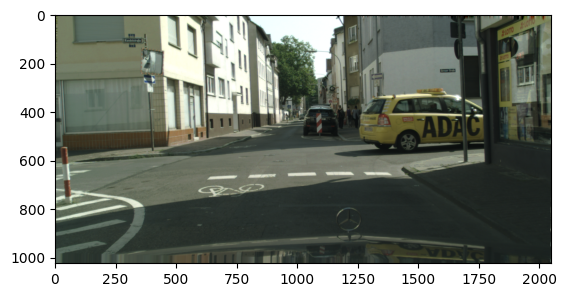

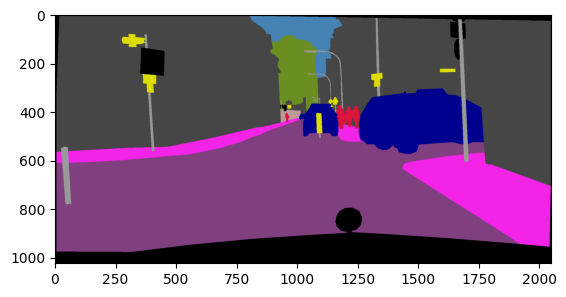

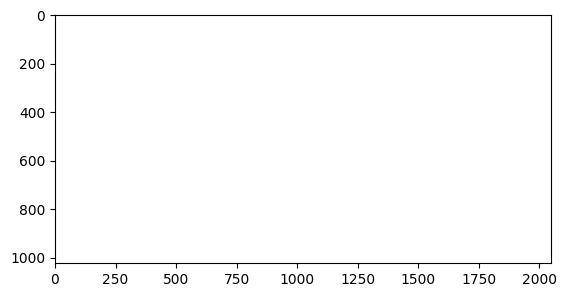

In [16]:
dir_rgb = rootdir+"cityscapes/leftImg8bit_trainvaltest/leftImg8bit/"
dir_seg = rootdir+"cityscapes/gtFine_trainvaltest/gtFine/"
dir_dep = rootdir+"cityscapes/disparity_trainvaltest/disparity/"
part = 'val/' #train val test
town = 'frankfurt/' #pilih salah satu kota

print(dir_rgb)
print(dir_seg)
print(dir_dep)

#------------------------------------------------
#load input dan outputnya

#RGB
#list semua file yang ada pada salah satu town di direktori RGB
list_file = os.listdir(dir_rgb+part+town)
list_file.sort() #urutkan
idx = 0
filename = list_file[idx] #ambil salah satu file
image = cv2.imread(dir_rgb+part+town+filename)
imagex = image[:, :, [2, 1, 0]]

#SEG
#list semua file yang ada pada salah satu town di direktori SEG
list_file = os.listdir(dir_seg+part+town)
list_file.sort() #urutkan
idx = 0
idx = 5*idx + 2
filename = list_file[idx] #ambil salah satu file
seg_gt = cv2.imread(dir_seg+part+town+filename)

#DEP
#list semua file yang ada pada salah satu town di direktori DEP
list_file = os.listdir(dir_dep+part+town)
list_file.sort() #urutkan
idx = 0
filename = list_file[idx] #ambil salah satu file
dep_gt = cv2.imread(dir_dep+part+town+filename, cv2.IMREAD_UNCHANGED).astype(np.float32)


#visualisasi image
plt.imshow(imagex)
plt.show()

#visualisasi GT segmentasi
seg_gtx = encode_labels(seg_gt, mapping_20)
seg_color = vis_seg(seg_gtx, SEG_MAP)
plt.imshow(seg_color.astype(np.uint8))
plt.show()

#visualisasi GT logarithmic depth
dep_gtx = disp2dep(dep_gt, 100)/100  #dinormalisasi ke 0 - 1
dep_log = logdepth(dep_gtx)
plt.imshow(dep_log.astype(np.uint8))
plt.show()



In [17]:
# #PREDIKSI TRAINED MODEL DARI DRIVE BEST MODEL
# model = resunet_mtl() #resunet_mtl
# model.load_state_dict(torch.load(rootdir+'trained_model/best_model.pth'))
# model.to(device, dtype=torch.float)
# input_img = np.expand_dims(resize_matrix(image, resize=4).transpose(2,0,1), axis=0) #buat jadi NxCxHxW
# input_img = torch.from_numpy(input_img).to(device, dtype=torch.float)
# print("input image shape", input_img.size())
# pred_seg, pred_dep = model(input_img)
# pred_seg = np.argmax(pred_seg.cpu().detach().numpy()[0], axis=0) #ambil batch 0 dan lakukan argmax
# print("output prediction shape", pred_seg.shape)
# pred_dep = pred_dep.cpu().detach().numpy()[0][0] #ambil batch 0 dan channel 0
# print("output prediction shape", pred_dep.shape)


# #visualisasi prediksi segmentasi
# pseg_color = vis_seg(pred_seg, SEG_MAP)
# plt.imshow(pseg_color.astype(np.uint8))
# plt.show()

# #visualisasi prediksi depth
# pdep_log = logdepth(pred_dep)
# plt.imshow(pdep_log.astype(np.uint8))
# plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


input image shape torch.Size([1, 3, 256, 512])
output prediction shape (256, 512)
output prediction shape (256, 512)


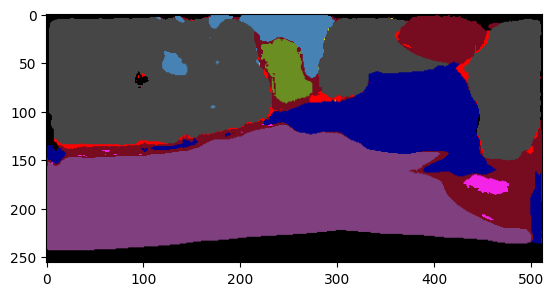

/tmp/ipykernel_12975/568987933.py:24: RuntimeWarning: divide by zero encountered in log
  logdepth = np.ones(normalized_depth.shape) + (np.log(normalized_depth) / 5.70378)


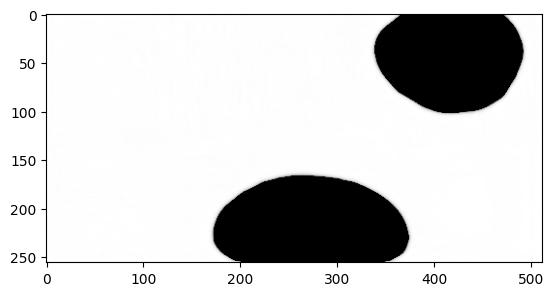

In [18]:
#PREDIKSI HASIL TRAINING
model = resunet_mtl() #resunet_mtl
model.load_state_dict(torch.load(save_dir+'model.pth'))
model.to(device, dtype=torch.float)
input_img = np.expand_dims(resize_matrix(image, resize=4).transpose(2,0,1), axis=0) #buat jadi NxCxHxW
input_img = torch.from_numpy(input_img).to(device, dtype=torch.float)
print("input image shape", input_img.size())
pred_seg, pred_dep = model(input_img)
pred_seg = np.argmax(pred_seg.cpu().detach().numpy()[0], axis=0) #ambil batch 0 dan lakukan argmax
print("output prediction shape", pred_seg.shape)
pred_dep = pred_dep.cpu().detach().numpy()[0][0] #ambil batch 0 dan channel 0
print("output prediction shape", pred_dep.shape)


#visualisasi prediksi segmentasi
pseg_color = vis_seg(pred_seg, SEG_MAP)
plt.imshow(pseg_color.astype(np.uint8))
plt.show()

#visualisasi prediksi depth
pdep_log = logdepth(pred_dep)
plt.imshow(pdep_log.astype(np.uint8))
plt.show()

E. TEST KE SELURUH SAMPLE
----------------

In [19]:
#FUNGSI IOU
def IOU(Yp, Yt):
    #.view(-1) artinya matrix tensornya di flatten kan dulu
    output = Yp.view(-1) > 0.5 #maksudnya yang lebih dari 0.5 adalah true
    target = Yt.view(-1) > 0.5 #dan yang kurang dari 0.5 adalah false
    intersection = (output & target).sum() #irisan
    union = (output | target).sum() #union
    #rumus IoU
    # print("intersection",intersection)
    # print("union",union)
    iou = intersection / union
    return iou

#FUNGSI TEST
def test(data_loader, model, device):
    #buat variabel untuk menyimpan kalkulasi loss
    metric_tm = AverageMeter()
    metric_seg = AverageMeter()
    metric_dep = AverageMeter()

    #buat dictionary log untuk menyimpan training log di CSV
    logx = OrderedDict([
        ('batch', []),
        ('test_tm', []),
        ('test_seg', []),
        ('test_mae', []),
        ('elapsed_time', [])])

    #masuk ke mode eval torch
    model.eval()

    with torch.no_grad():
        #visualisasi progress training dengan tqdm
        prog_bar = tqdm()
        prog_bar.reset(total=len(data_loader))

        #training....
        total_batch = len(data_loader)
        print(total_batch)
        #print(total_batch)
        batch_ke = 0
        for data in data_loader:
            seg_gt = data['seg'].to(device, dtype=torch.float)
            dep_gt = data['dep'].to(device, dtype=torch.float)
            image = data['rgb'].to(device, dtype=torch.float)

            #forward pass
            start_time = time.time() #waktu mulai
            pred_seg, pred_dep = model(image)
            elapsed_time = time.time() - start_time #hitung elapsedtime

            #kalkulasi metric
            iou = IOU(pred_seg, seg_gt)
            # print("iou")
            mae = F.l1_loss(pred_dep, dep_gt)
            tm = (1-iou) + mae

            #hitung rata-rata (avg) loss, dan metric untuk batch-batch yang telah diproses
            metric_tm.update(tm.item())
            metric_seg.update(iou.item())
            metric_dep.update(mae.item())

            #update visualisasi progress bar
            postfix = OrderedDict([('tm', metric_tm.avg),
                                  ('iou', metric_seg.avg),
                                  ('mae', metric_dep.avg)])

            #simpan ke log
            logx['batch'].append(batch_ke)
            logx['test_tm'].append(tm.item())
            logx['test_seg'].append(iou.item())
            logx['test_mae'].append(mae.item())
            logx['elapsed_time'].append(elapsed_time)
            pd.DataFrame(logx).to_csv(save_dir+'test_log.csv', index=False)

            batch_ke += 1
            prog_bar.set_postfix(postfix)
            prog_bar.update()
        prog_bar.refresh()

        #ketika semua sudah selesai, hitung rata2 performa pada log
        logx['batch'].append("avg")
        logx['test_tm'].append(np.mean(logx['test_tm']))
        logx['test_seg'].append(np.mean(logx['test_seg']))
        logx['test_mae'].append(np.mean(logx['test_mae']))
        logx['elapsed_time'].append(np.mean(logx['elapsed_time']))
        pd.DataFrame(logx).to_csv(save_dir+'test_log.csv', index=False)

    return postfix


#BUAT DATA BATCH: NxCxHxW
test_set = myData(root_dir=dataset_dir, part='test')
print("Jumlah sample test: "+str(len(test_set)))
dataloader_test = DataLoader(test_set, batch_size=1, shuffle=False, num_workers=6, drop_last=True)

start_time = time.time() #waktu mulai
test_log = test(dataloader_test, model, device)
elapsed_time = time.time() - start_time #hitung elapsedtime
print(test_log)
print(elapsed_time)
torch.cuda.empty_cache()

Jumlah sample test: 5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


0it [00:00, ?it/s]

5


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


OrderedDict({'tm': 1.0529031991958617, 'iou': 0.026660840213298797, 'mae': 0.07956402897834777})
3.22078013420105
